# 06_12 - Fig. 4G DIU restriction, WITHOUT depth correction

In [2]:
# relocation-proof bootstrap
import os
import sys

_d = os.path.abspath(os.getcwd())
while not os.path.exists(os.path.join(_d, '.notebooks_root')):
    _p = os.path.dirname(_d)
    if _p == _d:
        raise RuntimeError('could not locate .notebooks_root above this notebook')
    _d = _p
os.chdir(_d)
if _d not in sys.path:
    sys.path.insert(0, _d)
print('working dir:', os.getcwd())

import gc
import warnings
from collections import Counter

import numpy as np
import pandas as pd
from scipy import stats
from scipy.sparse import issparse, csr_matrix, coo_matrix
import matplotlib
import matplotlib.pyplot as plt

import importlib
import figure_paths
importlib.reload(figure_paths)
from figure_paths import figpath
import senescence_robustness as sr
importlib.reload(sr)

warnings.filterwarnings('ignore', category=RuntimeWarning)
pd.set_option('display.width', 240)

working dir: /oak/stanford/groups/quake/mmantri/group.quake/tabula_longread/notebooks


In [3]:
# preferred plot formatting
TICK_LEN = 2.0
TICK_LABEL_PAD = 1.5
AXIS_LABEL_PAD = 1.5
PANEL_TITLE_PAD = 3.0
plt.rcParams.update({
    'font.size': 6, 'axes.titlesize': 6, 'axes.labelsize': 6,
    'xtick.labelsize': 6, 'ytick.labelsize': 6,
    'legend.fontsize': 6, 'legend.title_fontsize': 6,
    'legend.labelspacing': 0.1, 'legend.borderpad': 0.3, 'legend.handletextpad': 0.2,
    'figure.titlesize': 6,
    'axes.labelweight': 'bold', 'axes.titleweight': 'bold', 'figure.titleweight': 'bold',
    'xtick.major.size': TICK_LEN, 'ytick.major.size': TICK_LEN,
    'xtick.major.pad': TICK_LABEL_PAD, 'ytick.major.pad': TICK_LABEL_PAD,
    'axes.labelpad': AXIS_LABEL_PAD,
})
matplotlib.rcParams['pdf.fonttype'] = 42
matplotlib.rcParams['ps.fonttype'] = 42
matplotlib.rcParams['font.family'] = 'sans-serif'
matplotlib.rcParams['font.sans-serif'] = ['Arial'] + matplotlib.rcParams['font.sans-serif']
matplotlib.rcParams['mathtext.fontset'] = 'custom'
matplotlib.rcParams['mathtext.rm'] = 'Arial'
matplotlib.rcParams['mathtext.it'] = 'Arial:italic'
matplotlib.rcParams['mathtext.bf'] = 'Arial:bold'
matplotlib.rcParams['mathtext.cal'] = 'Arial:italic'
matplotlib.rcParams['mathtext.sf'] = 'Arial'
matplotlib.rcParams['mathtext.tt'] = 'Arial'


def despine(ax):
    for _s in ('top', 'right'):
        ax.spines[_s].set_visible(False)


SIG_COLOR = '#c44e52'
NULL_COLOR = '#4c72b0'
UNDERPOWERED_COLOR = '#d9d9d9'
PUB_COLOR = '#8172b3'

H5AD_DIR = '../pacbio/h5ads'
CSV_DIR = '../csvs'
OUT = CSV_DIR + '/06_36_robustness'
os.makedirs(OUT, exist_ok=True)
OBJ = (H5AD_DIR + '/all_samples_pacbio_recollapsed_raw_counts_ensemblids_annotatedonly'
       '_bc_anndata_preprocessed_with_isofrac_xgen_cdkn2a.h5ad')
DM_DIU = CSV_DIR + '/06_04_dm_diu_per_celltype.csv'
STATUS_COL = 'xgen_cdkn2a_raw_status'
# obs['total_counts'] is STALE on a _with_isofrac object: 01_08 computes it
# per level as X.sum(axis=1), then 01_09 drops the single-isoform genes
# WITHOUT recomputing it, so the stored value is a library size over the
# pre-drop feature set. Recomputed from this object's own X at load.
DEPTH = 'iso_total_counts'

# N_BINS is 3 rather than 06_11's 5: the downsampling arm puts only 50 senescent
# cells in a class, and 5 strata would leave 10 per stratum -- below the floor,
# so most classes would drop out of the very comparison the arm exists to make.
# --- NO DEPTH CORRECTION (see header) -------------------------------------
# n_bins=1 puts every cell in one stratum, turning the stratified estimators
# into plain within-unit comparisons. This flag is the only difference from
# the parent notebook.
DEPTH_CORRECTION = False
N_BINS = 3 if DEPTH_CORRECTION else 1
MIN_CELLS_PER_ARM = 5      # per (class, stratum, arm) for that stratum to count
MIN_SEN_PER_CLASS = 30     # classes below this are reported untested, not dropped
ALPHA = 0.05
POWER_Z = 2.802            # z(0.975) + z(0.80): 80% power at alpha = 0.05
SUB_LEVELS = (50, 100)     # senescent cells per class in the matched-power arm
N_REP = 3
REF_MULT = 4               # reference cells kept per senescent cell
CHUNK = 8000
SEED = 0

final = {}

## 1. The published pattern and the power gradient behind it


In [4]:
dm = pd.read_csv(DM_DIU, usecols=['gene', 'names', 'broad_cell_class',
                                  'dm_pvals_adj', 'tv_distance',
                                  'delta_fraction', 'tested',
                                  'n_cells_group', 'n_cells_ref'])
dm['tested'] = dm['tested'].astype(str).str.lower() == 'true'

# one row per (class, gene): the DM p is a GENE-level statistic broadcast to the
# gene's isoforms, so deduplicate before counting anything
gl = (dm[dm.tested]
      .groupby(['broad_cell_class', 'gene'])
      .agg(padj=('dm_pvals_adj', 'min'), tv=('tv_distance', 'max'),
           n_sen=('n_cells_group', 'max'), n_ref=('n_cells_ref', 'max'),
           n_iso=('names', 'size'))
      .reset_index())
gl['sig'] = gl['padj'] < ALPHA
print(f'(class, gene) pairs tested : {len(gl):,}')
print(f'significant                : {int(gl.sig.sum()):,}')

pub = (gl.groupby('broad_cell_class')
       .agg(n_sen=('n_sen', 'max'), tested=('gene', 'size'),
            sig=('sig', 'sum')).reset_index())
pub['pct_sig'] = 100 * pub['sig'] / pub['tested']
pub = pub.sort_values('n_sen', ascending=False)
print()
print('AS PUBLISHED, per class:')
print(pub.round(2).to_string(index=False))

_r = stats.spearmanr(pub['n_sen'], pub['sig'])
print()
print(f'Spearman(senescent cells, significant genes) = {_r[0]:+.3f}, p = {_r[1]:.2g}')
print('A power gradient and a biological gradient both predict this. It is the')
print('reason the panel cannot settle the question on its own.')

n_by_gene = gl[gl.sig].groupby('gene').size()
hist_pub = n_by_gene.value_counts().sort_index()
n_genes_sig = len(n_by_gene)
print()
print(f'genes significant in >=1 class: {n_genes_sig:,}')
for k, v in hist_pub.items():
    print(f'  {k:>2} class(es): {v:>5,} genes  ({100 * v / n_genes_sig:5.1f}%)')
pub_1 = 100 * hist_pub.get(1, 0) / n_genes_sig
pub_12 = 100 * (hist_pub.get(1, 0) + hist_pub.get(2, 0)) / n_genes_sig
print()
print(f'exactly 1 class : {pub_1:.1f}%      1 or 2 classes : {pub_12:.1f}%')

top_cls = pub.iloc[0]['broad_cell_class']
share = 100 * int(gl[gl.sig & (gl.broad_cell_class == top_cls)].shape[0]) \
    / max(int(gl.sig.sum()), 1)
only_top = gl[gl.sig].groupby('gene')['broad_cell_class'].apply(
    lambda s: len(s) == 1 and s.iloc[0] == top_cls).sum()
print()
print(f'share of all significant pairs in {top_cls!r}: {share:.1f}%')
print(f'genes significant ONLY in {top_cls!r}: {int(only_top):,} '
      f'({100 * only_top / n_genes_sig:.1f}% of all significant genes)')
print('If most "cell-type-restricted" genes are restricted to the single')
print('best-powered class, "restricted" is doing no work in that sentence.')
final['pub_pct_1_class'] = pub_1
final['pub_pct_1or2_class'] = pub_12
final['pub_n_genes_sig'] = n_genes_sig
final['pub_top_class'] = top_cls
final['pub_top_class_share_of_pairs'] = share
final['pub_genes_only_top_class'] = int(only_top)
final['pub_spearman_n_vs_sig'] = float(_r[0])
pub.to_csv(OUT + '/06_12_published_per_class.csv', index=False)
print('best-powered class, "restricted" is doing no work in that sentence.')

(class, gene) pairs tested : 66,586
significant                : 5,419

AS PUBLISHED, per class:
            broad_cell_class  n_sen  tested  sig  pct_sig
              male germ cell   1340   10566 2723    25.77
     lymphocyte of b lineage    487    8275 1058    12.79
           myeloid leukocyte    278    8159  769     9.43
                  fibroblast    186    5965   64     1.07
transitional epithelial cell    166    5195  133     2.56
                      t cell    148    4624  282     6.10
                   stem cell    115    3034   58     1.91
    ciliated epithelial cell     77    5317   95     1.79
  stratified epithelial cell     59    2625   20     0.76
   glandular epithelial cell     50    3654   48     1.31
        endo-epithelial cell     39    3264   38     1.16
            contractile cell     34    1421   23     1.62
  intestinal epithelial cell     32    1771  103     5.82
                stromal cell     28    1013    3     0.30
            endothelial cell     

## 2. A common effect scale: stratified isoform-fraction change with an SE


In [5]:
import scanpy as sc

adata = sc.read_h5ad(OBJ)
# depth on THIS object's feature set, not the stale obs column (see header)
adata.obs['iso_total_counts'] = np.asarray(adata.X.sum(axis=1)).ravel()
st = adata.obs[STATUS_COL].astype(str)
adata = adata[(~st.isin(['other_CDKN2A+', 'p14ARF+'])).values].copy()
st = adata.obs[STATUS_COL].astype(str)
sen = st.isin(['p16+', 'Both']).values
print(f'{adata.n_obs:,} cells x {adata.n_vars:,} transcript structures')

# gene_name, NOT pigeon_associated_gene: the DM table keys on SYMBOLS, and an
# ENSG-keyed join would silently match nothing.
gname = adata.var['gene_name'].astype(str).values
keep_genes = set(n_by_gene.index.astype(str))
col_keep = np.isin(gname, np.array(sorted(keep_genes)))
adata = adata[:, col_keep].copy()
gname = adata.var['gene_name'].astype(str).values
iso_names = adata.var_names.values.astype(str)
# build_iso_to_gene returns the per-isoform gene index AND the per-gene
# isoform-column lists; rebuilding either by hand risks a silent mismatch
# in ordering, so both are taken from the helper.
iso_to_gene, gene_of_iso, genes, gene_cols = sr.build_iso_to_gene(gname)
n_genes = len(genes)
gene_pos = {g: i for i, g in enumerate(genes)}
print(f'scope: {n_genes:,} genes significant somewhere -> '
      f'{adata.n_vars:,} isoform columns')

cls_all = adata.obs['broad_cell_class'].astype(str).values
sen_per_class = pd.Series(cls_all[sen]).value_counts()
classes = sorted([c for c in sen_per_class.index
                  if sen_per_class[c] >= MIN_SEN_PER_CLASS])
excluded = sorted([c for c in sen_per_class.index
                   if sen_per_class[c] < MIN_SEN_PER_CLASS])
n_cls = len(classes)
cls_idx = {c: i for i, c in enumerate(classes)}
print(f'\nsenescent cells per class: {sen_per_class.min()} to '
      f'{sen_per_class.max()} '
      f'({sen_per_class.max() / max(sen_per_class.min(), 1):.0f}x range)')
print(f'classes analysed (>= {MIN_SEN_PER_CLASS} senescent): {n_cls}')
print(f'classes UNTESTED (too few): {len(excluded)} -> {excluded}')

dbin = sr.depth_bin(adata.obs[DEPTH].values, n_bins=N_BINS)
ci_all = np.array([cls_idx.get(c, -1) for c in cls_all])

# --- donor axis, for the direction-consistency filter -----------------------
# One extra accumulator block per donor, so a per-donor effect can be computed with the SAME
# estimator as the pooled one rather than a second, differently-defined statistic. Cost is
# n_don * GPB extra group rows -- ~26 rows per donor here, against 182 already allocated.
donor_arr = adata.obs['donor'].astype(str).values
don_list = sorted(set(donor_arr))
n_don = len(don_list)
don_idx = np.array([don_list.index(d) for d in donor_arr])
print(f'donors: {don_list}')

# --- downsampling plan, fixed before any effect is computed -----------------
rng = np.random.default_rng(SEED)
COMBOS = [(lev, r) for lev in SUB_LEVELS for r in range(N_REP)]
n_combo = len(COMBOS)
keep = np.zeros((n_combo, adata.n_obs), dtype=bool)
combo_classes = []
for k, (lev, r) in enumerate(COMBOS):
    incl = []
    for c in classes:
        m = cls_all == c
        idx_s = np.where(m & sen)[0]
        idx_r = np.where(m & ~sen)[0]
        if len(idx_s) < lev or len(idx_r) < lev:
            continue
        keep[k, rng.choice(idx_s, lev, replace=False)] = True
        keep[k, rng.choice(idx_r, min(len(idx_r), lev * REF_MULT),
                           replace=False)] = True
        incl.append(c)
    combo_classes.append(incl)
print()
for k, (lev, r) in enumerate(COMBOS):
    print(f'  n={lev:>3} rep {r}: {len(combo_classes[k]):>2} classes, '
          f'{int(keep[k].sum()):,} cells')
print('Classes with fewer senescent cells than the level are EXCLUDED from that')
print('rung rather than padded -- so each rung is a genuinely equal-n comparison.')

# --- accumulate ------------------------------------------------------------
frac = adata.layers['isoform_fraction']
frac = frac.tocsr() if issparse(frac) else csr_matrix(frac)
n_iso = adata.n_vars
GPB = n_cls * N_BINS * 2                 # groups per block
n_groups = GPB * (1 + n_combo + n_don)   # base + one per downsample combo + one per donor
ss = np.zeros((n_groups, n_iso), dtype=np.float64)
sq = np.zeros((n_groups, n_iso), dtype=np.float64)
nn = np.zeros((n_groups, n_genes), dtype=np.float64)
print(f'\naccumulators: {n_groups} groups x {n_iso:,} isoforms '
      f'-> {ss.nbytes / 1e6:.0f} MB each')

base_g = np.where(ci_all >= 0,
                  ci_all * (N_BINS * 2) + dbin * 2 + sen.astype(int), -1)
for start in range(0, adata.n_obs, CHUNK):
    end = min(start + CHUNK, adata.n_obs)
    b = frac[start:end]
    bg = base_g[start:end]
    rows, cols = [], []
    ok = np.where(bg >= 0)[0]
    rows.append(ok)
    cols.append(bg[ok])
    for k in range(n_combo):
        kk = np.where((bg >= 0) & keep[k, start:end])[0]
        rows.append(kk)
        cols.append(GPB * (1 + k) + bg[kk])
    # one block per donor: same (class, stratum, arm) layout, that donor's cells only
    _di = don_idx[start:end]
    for d in range(n_don):
        dd = np.where((bg >= 0) & (_di == d))[0]
        rows.append(dd)
        cols.append(GPB * (1 + n_combo + d) + bg[dd])
    rows = np.concatenate(rows)
    cols = np.concatenate(cols)
    # DENSE group indicator, and sparse-times-DENSE products. The obvious
    # G.T @ b is sparse-times-sparse with a near-dense result: scipy builds it
    # as a sparse matrix first (~1e8 stored entries) before densifying, which
    # costs several GB and is far slower than writing straight into an ndarray.
    # Gd itself is only n_chunk x n_groups (~35 MB).
    Gd = np.zeros((end - start, n_groups), dtype=np.float64)
    Gd[rows, cols] = 1.0
    ss += b.T.dot(Gd).T
    sq += b.multiply(b).T.dot(Gd).T
    meas = ((b > 0).astype(np.float32) @ iso_to_gene)
    meas.data = np.ones_like(meas.data)          # gene expressed in this cell
    nn += meas.T.dot(Gd).T
    del b, Gd, meas
    gc.collect()
    print(f'  {end:,}/{adata.n_obs:,}', flush=True)
print('accumulation done')

obs_keep = adata.obs[['broad_cell_class', 'donor', 'tube_id']].copy()
del adata, frac
gc.collect()

154,182 cells x 130,362 transcript structures
scope: 4,006 genes significant somewhere -> 39,694 isoform columns

senescent cells per class: 1 to 1340 (1340x range)
classes analysed (>= 30 senescent): 13
classes UNTESTED (too few): 15 -> ['cardiac endothelial cell', 'dendritic cell', 'duct epithelial cell', 'ecto-epithelial cell', 'endothelial cell', 'epithelial cell', 'epithelial cell of lung', 'erythroid lineage cell', 'granulocyte', 'hematopoietic cell', 'innate lymphoid cell', 'melanocyte', 'meso-epithelial cell', 'stromal cell', 'vestibular dark cell']
donors: ['TSP21', 'TSP25', 'TSP27', 'TSP33']

  n= 50 rep 0: 10 classes, 2,500 cells
  n= 50 rep 1: 10 classes, 2,500 cells
  n= 50 rep 2: 10 classes, 2,500 cells
  n=100 rep 0:  7 classes, 3,500 cells
  n=100 rep 1:  7 classes, 3,500 cells
  n=100 rep 2:  7 classes, 3,500 cells
Classes with fewer senescent cells than the level are EXCLUDED from that
rung rather than padded -- so each rung is a genuinely equal-n comparison.

accumul

0

## 3. Per-(gene, class) switch effects


In [6]:
gi_of_iso = gene_of_iso          # from build_iso_to_gene, not rebuilt


def block_effects(ss_, sq_, nn_, cl):
    """Per-isoform stratified effect and SE for one class within one block."""
    off = cl * (N_BINS * 2)
    eff_num = np.zeros(n_iso)
    wsum = np.zeros(n_iso)
    for s in range(N_BINS):
        g_ref, g_sen = off + s * 2 + 0, off + s * 2 + 1
        n_ref = nn_[g_ref][gi_of_iso]
        n_sen = nn_[g_sen][gi_of_iso]
        good = (n_ref >= MIN_CELLS_PER_ARM) & (n_sen >= MIN_CELLS_PER_ARM)
        if not good.any():
            continue
        with np.errstate(invalid='ignore', divide='ignore'):
            m_ref = ss_[g_ref] / n_ref
            m_sen = ss_[g_sen] / n_sen
            v_ref = (sq_[g_ref] / n_ref - m_ref ** 2) * n_ref / np.maximum(n_ref - 1, 1)
            v_sen = (sq_[g_sen] / n_sen - m_sen ** 2) * n_sen / np.maximum(n_sen - 1, 1)
            se2 = np.maximum(v_ref, 0) / n_ref + np.maximum(v_sen, 0) / n_sen
            w = 1.0 / se2
        w = np.where(good & np.isfinite(w) & (w > 0), w, 0.0)
        d = np.where(good, m_sen - m_ref, 0.0)
        eff_num += w * np.nan_to_num(d)
        wsum += w
    with np.errstate(invalid='ignore', divide='ignore'):
        eff = np.where(wsum > 0, eff_num / wsum, np.nan)
        se = np.where(wsum > 0, np.sqrt(1.0 / wsum), np.nan)
    return eff, se


iso_eff = np.full((n_cls, n_iso), np.nan)
iso_se = np.full((n_cls, n_iso), np.nan)
for c in range(n_cls):
    iso_eff[c], iso_se[c] = block_effects(ss, sq, nn, c)
print(f'isoform-level effects: {np.isfinite(iso_eff).sum():,} of '
      f'{iso_eff.size:,} (class, isoform) cells estimable')

# --- pick the switch isoform ONCE, in the discovery class -------------------
# Restrict to ANALYSED classes BEFORE choosing the discovery class. Filtering
# afterwards would silently delete every gene whose single best class happens to
# be one of the under-30-cell classes, shrinking the denominator of the very
# restriction statistic this notebook is auditing.
sig_tab = gl[gl.sig & gl.broad_cell_class.isin(classes)].copy()
disc = (sig_tab.sort_values('padj')
        .drop_duplicates('gene')[['gene', 'broad_cell_class', 'padj']]
        .rename(columns={'broad_cell_class': 'discovery_class'}))
_lost = int(gl[gl.sig].gene.nunique() - len(disc))
print(f'genes whose only significant class is below the {MIN_SEN_PER_CLASS}-cell '
      f'floor, so untestable here: {_lost:,}')
print(f'genes with a discovery class among the {n_cls} analysed: {len(disc):,}')

iso_by_gene = {i: cols for i, cols in enumerate(gene_cols)}

sw_rows = []
for g, dcls, dpadj in zip(disc.gene, disc.discovery_class, disc.padj):
    gidx = gene_pos.get(g)
    if gidx is None:
        continue
    cols = iso_by_gene.get(gidx)
    if cols is None or len(cols) < 2:
        continue
    c = cls_idx[dcls]
    e = iso_eff[c, cols]
    if not np.any(np.isfinite(e)):
        continue
    j = int(cols[int(np.nanargmax(np.abs(e)))])
    sw_rows.append({'gene': g, 'gene_idx': gidx, 'iso_idx': j,
                    'switch_isoform': iso_names[j], 'discovery_class': dcls,
                    'discovery_padj': dpadj,
                    'discovery_effect': float(iso_eff[c, j]),
                    'discovery_se': float(iso_se[c, j]),
                    'n_isoforms': int(len(cols))})
sw = pd.DataFrame(sw_rows)
sw = sw[np.isfinite(sw.discovery_effect) & np.isfinite(sw.discovery_se)]
print(f'switches defined for {len(sw):,} genes')
print(f"median |discovery effect|: {np.abs(sw.discovery_effect).median():.4f} "
      'fraction units')
final['n_switch_genes'] = len(sw)

# --- validation against the published unstratified delta_fraction ----------
pubd = dm.set_index(['broad_cell_class', 'gene', 'names'])['delta_fraction']
pubd = pubd[~pubd.index.duplicated()].sort_index()   # sorted: ~7k lookups
chk = []
for g, dcls, j, e in zip(sw.gene, sw.discovery_class, sw.iso_idx,
                         sw.discovery_effect):
    try:
        chk.append((float(pubd.loc[(dcls, g, iso_names[j])]), e))
    except KeyError:
        pass
chk = np.array(chk)
if len(chk) > 50:
    rho = stats.spearmanr(chk[:, 0], chk[:, 1])[0]
    agree = float(np.mean(np.sign(chk[:, 0]) == np.sign(chk[:, 1])))
    print(f'\nVALIDATION vs published delta_fraction on {len(chk):,} switches:')
    print(f'  Spearman {rho:+.3f} | sign agreement {100 * agree:.1f}%')
    print('  Not expected to be 1.0 -- these are depth-stratified, those are not.')
    final['validation_spearman_vs_published'] = float(rho)
    final['validation_sign_agreement'] = 100 * agree

isoform-level effects: 299,111 of 516,022 (class, isoform) cells estimable
genes whose only significant class is below the 30-cell floor, so untestable here: 0
genes with a discovery class among the 13 analysed: 4,006
switches defined for 4,005 genes
median |discovery effect|: 0.1315 fraction units

VALIDATION vs published delta_fraction on 3,985 switches:
  Spearman +0.999 | sign agreement 100.0%
  Not expected to be 1.0 -- these are depth-stratified, those are not.


## 4. Restriction or underpowering? The trichotomy and the equivalence test


In [7]:
gi = sw.gene_idx.values
ji = sw.iso_idx.values
E = iso_eff[:, ji]                       # [class, gene]
S = iso_se[:, ji]
disc_c = np.array([cls_idx[c] for c in sw.discovery_class])
ref_eff = np.abs(sw.discovery_effect.values)

with np.errstate(invalid='ignore', divide='ignore'):
    Z = E / S
P = 2 * stats.norm.sf(np.abs(Z))
PADJ = np.full_like(P, np.nan)
for c in range(n_cls):
    PADJ[c] = sr.bh(P[c])          # sr.bh passes NaN through unchanged
SIG = PADJ < ALPHA
EST = np.isfinite(E) & np.isfinite(S)
MDE = POWER_Z * S

# equivalence: does this class's 95% CI exclude the discovery-class effect?
hi = np.abs(E) + 1.96 * S
excludes_ref = hi < ref_eff[None, :]
verdict = np.full(E.shape, 'not estimable', dtype=object)
verdict[EST & SIG] = 'affected'
verdict[EST & ~SIG & excludes_ref] = 'genuinely null'
verdict[EST & ~SIG & ~excludes_ref] = 'underpowered'
for k, c in enumerate(disc_c):
    verdict[c, k] = 'discovery'

rows = []
for c in range(n_cls):
    v = verdict[c]
    rows.append({'broad_cell_class': classes[c],
                 'n_sen': int(sen_per_class[classes[c]]),
                 'discovery': int((v == 'discovery').sum()),
                 'affected': int((v == 'affected').sum()),
                 'genuinely_null': int((v == 'genuinely null').sum()),
                 'underpowered': int((v == 'underpowered').sum()),
                 'not_estimable': int((v == 'not estimable').sum()),
                 'median_MDE': float(np.nanmedian(MDE[c]))})
vs = pd.DataFrame(rows).sort_values('n_sen', ascending=False)
vs['pct_underpowered'] = 100 * vs.underpowered / (vs.underpowered + vs.genuinely_null).clip(lower=1)
vs.to_csv(OUT + '/06_12_restriction_verdicts.csv', index=False)
print(vs.round(4).to_string(index=False))

n_up = int((verdict == 'underpowered').sum())
n_gn = int((verdict == 'genuinely null').sum())
pct_up = 100 * n_up / max(n_up + n_gn, 1)
print()
print(f'non-discovery, non-significant (gene, class) pairs:')
print(f'  genuinely null (CI excludes the discovery effect) : {n_gn:,}')
print(f'  underpowered   (CI still admits it)               : {n_up:,}')
print(f'  -> {pct_up:.1f}% of apparent restriction is underpowering')
print()
print(f'median MDE ranges {vs.median_MDE.min():.4f} to {vs.median_MDE.max():.4f} '
      f'({vs.median_MDE.max() / max(vs.median_MDE.min(), 1e-9):.0f}x across classes)')
final['n_genuinely_null'] = n_gn
final['n_underpowered'] = n_up
final['pct_underpowered'] = pct_up
final['mde_ratio'] = float(vs.median_MDE.max() / max(vs.median_MDE.min(), 1e-9))

# restriction histogram after the power correction: count only classes that had
# a real chance, i.e. treat 'underpowered' as MISSING rather than as absent
n_aff = (verdict == 'affected').sum(axis=0) + 1          # + discovery
n_informative = ((verdict == 'affected') | (verdict == 'genuinely null')).sum(axis=0) + 1
hist_corr = Counter(n_aff.tolist())
print()
print('RESTRICTION, recomputed on the common switch scale:')
for k in sorted(hist_corr):
    print(f'  {k:>2} class(es): {hist_corr[k]:>5,} genes '
          f'({100 * hist_corr[k] / len(sw):5.1f}%)')
corr_1 = 100 * hist_corr.get(1, 0) / len(sw)
print()
print(f'exactly 1 class, common scale : {corr_1:.1f}%   '
      f'(published: {pub_1:.1f}%)')
print(f'median classes with an INFORMATIVE readout per gene: '
      f'{np.median(n_informative):.0f} of {n_cls}')
final['corrected_pct_1_class'] = corr_1
final['median_informative_classes'] = float(np.median(n_informative))

pd.DataFrame({'gene': sw.gene.values,
              'discovery_class': sw.discovery_class.values,
              'switch_isoform': sw.switch_isoform.values,
              'discovery_effect': sw.discovery_effect.values,
              'n_classes_affected': n_aff,
              'n_classes_informative': n_informative}).to_csv(
    OUT + '/06_12_per_gene_restriction.csv', index=False)

# FULL (gene, class) MATRIX.
#
# Everything above collapses this axis: restriction_verdicts.csv keeps per-class COUNTS, and
# per_gene_restriction.csv keeps one row per gene, its DISCOVERY row. The 'affected' pairs -- a
# gene significant in a class OTHER than the one it was discovered in -- therefore survived
# nowhere on disk, even though they outnumber the discovery rows and are the direct evidence
# that switches are shared across classes rather than confined to one.
#
# E / S / Z / PADJ / MDE / verdict are all [class, gene] over the same two axes, so one ravel
# each writes the lot. Class-major order: the first len(sw) rows are classes[0], and so on.
_n_g = len(sw)

# --- per-donor direction, for the donor-consistency filter -------------------
# Each donor has its own accumulator block, so a donor's effect for a gene's switch isoform in a
# class is block_effects run on that donor's block alone -- the same estimator as the pooled
# effect, not a second statistic that would have to be calibrated against it.
#
# CONCORDANT means finite AND same sign as the pooled effect. A donor in which the (gene, class)
# cell is NOT estimable is counted in neither direction: absence of an estimate is not
# disagreement, and treating it as such would penalise exactly the small classes whose lack of
# power this notebook exists to document.
D = np.full((n_don, n_cls, _n_g), np.nan)
for _d in range(n_don):
    _off = GPB * (1 + n_combo + _d)
    for _c in range(n_cls):
        _e, _ = block_effects(ss[_off:_off + GPB], sq[_off:_off + GPB],
                              nn[_off:_off + GPB], _c)
        D[_d, _c] = _e[ji]
n_don_est = np.isfinite(D).sum(axis=0)                                  # [class, gene]
n_don_conc = (np.isfinite(D) & (np.sign(D) == np.sign(E)[None, :, :])).sum(axis=0)
print()
print(f'per-donor effects: {n_don} donors x {n_cls} classes x {_n_g:,} genes; '
      f'{int(np.isfinite(D).sum()):,} of {D.size:,} estimable')
_sigmask = np.isin(verdict, ('discovery', 'affected'))
for _k in range(n_don + 1):
    _m = _sigmask & (n_don_conc == _k)
    print(f'  significant pairs with {_k} concordant donor(s): {int(_m.sum()):,}')

# long-form per-donor table, so the filter can be audited or re-cut at another threshold
pd.DataFrame({
    'donor': np.repeat(np.asarray(don_list, dtype=object), n_cls * _n_g),
    'broad_cell_class': np.tile(np.repeat(np.asarray(classes, dtype=object), _n_g), n_don),
    'gene': np.tile(np.asarray(sw.gene.values, dtype=object), n_don * n_cls),
    'effect_donor': D.ravel(),
}).to_csv(OUT + '/06_12_gene_class_donor_effects.csv', index=False)
print(f'wrote 06_12_gene_class_donor_effects.csv: {D.size:,} rows')

gc_matrix = pd.DataFrame({
    'broad_cell_class': np.repeat(np.asarray(classes, dtype=object), _n_g),
    'n_sen': np.repeat(np.array([int(sen_per_class[c]) for c in classes]), _n_g),
    'gene': np.tile(np.asarray(sw.gene.values, dtype=object), n_cls),
    'switch_isoform': np.tile(np.asarray(sw.switch_isoform.values, dtype=object), n_cls),
    'discovery_class': np.tile(np.asarray(sw.discovery_class.values, dtype=object), n_cls),
    'effect': E.ravel(),
    'se': S.ravel(),
    'z': Z.ravel(),
    'padj': PADJ.ravel(),
    'mde': MDE.ravel(),
    'significant': SIG.ravel(),
    'verdict': verdict.ravel(),
    'n_donors_estimable': n_don_est.ravel(),
    'n_donors_concordant': n_don_conc.ravel(),
})
gc_matrix.to_csv(OUT + '/06_12_gene_class_matrix.csv', index=False)

_n_disc = int((gc_matrix.verdict == 'discovery').sum())
_n_aff = int((gc_matrix.verdict == 'affected').sum())
print()
print(f'wrote 06_12_gene_class_matrix.csv: {len(gc_matrix):,} rows '
      f'= {_n_g:,} switch genes x {n_cls} classes')
print(f'  significant pairs : {_n_disc + _n_aff:,}  '
      f'({_n_disc:,} discovery + {_n_aff:,} affected elsewhere)')
print(f'  per_gene_restriction.csv carries only the {_n_disc:,} discovery rows, i.e. '
      f'{100 * _n_disc / max(_n_disc + _n_aff, 1):.0f}% of them.')
print('  Gene ids follow sw.gene: symbols where one exists, ENSG for the rest '
      f'({100 * pd.Series(sw.gene.values).astype(str).str.startswith("ENSG").mean():.1f}% ENSG).')

            broad_cell_class  n_sen  discovery  affected  genuinely_null  underpowered  not_estimable  median_MDE  pct_underpowered
              male germ cell   1340       2521       234             459           451            340      0.0877           49.5604
     lymphocyte of b lineage    487        711       390             968           744           1192      0.0893           43.4579
           myeloid leukocyte    278        482       399            1006           985           1133      0.1025           49.4726
                  fibroblast    186         19       364             782          1523           1317      0.1505           66.0738
transitional epithelial cell    166         54       438             659          1244           1610      0.1320           65.3705
                      t cell    148         72       531             481          1311           1610      0.1545           73.1585
                   stem cell    115         13       416             333    

## 6. Figures


In [8]:
pd.Series(final).to_csv(OUT + '/06_12_final_numbers.csv', header=['value'])

            broad_cell_class  n_sen                           top_up                               top_down
              male germ cell   1340 ENSG00000251600, SPATA5, SLC36A4 RFX7, ENSG00000234352, ENSG00000235538
     lymphocyte of b lineage    487               ZNF791, WDR19, MAF        CLEC16A, TXLNB, ENSG00000288663
           myeloid leukocyte    278         MIR4458HG, MSI2, TRG-AS1                  GTF2H5, ZNF576, MYLIP
                  fibroblast    186          FBXO5, CENPS, MIR4458HG                   RRM2, HSD17B7, EARS2
transitional epithelial cell    166            PJA1, AP1S1, MIR222HG                    UQCR11, ITGAE, GNG5
                      t cell    148              VPS37B, LSM7, FANCA                 SMAP1, EXOSC1, ZNF271P
                   stem cell    115              IDH2, PRMT2, GPANK1                  MRPS7, PNRC1, PPP1R10
    ciliated epithelial cell     77      KBTBD3, C1orf174, LINC02482                  RHNO1, EXOC6, ATP5IF1
  stratified epithelial cell

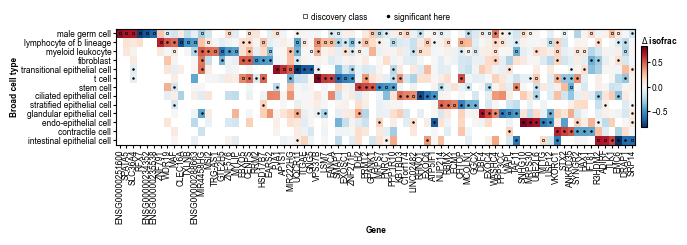

  06_12_pub_H_top5_diu_no_power.pdf


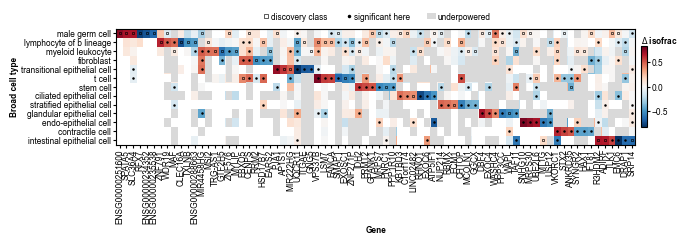

  06_12_pub_H_top5_diu_with_power.pdf

(H) Change in isoform fraction for the 3 largest increases
    and 3 largest decreases in isoform fraction among the
    senescence-associated isoform switches of each broad cell class (union across
    classes), shown in every class. Open square marks the class the switch was
    defined in; filled dot marks a class where it is independently significant;
    white marks a class where the switch was not estimable. In the second panel,
    grey marks a class whose confidence interval could not have excluded the
    discovery-class effect, i.e. one that was not powered to detect it -- 42% of estimable class-switch pairs shown.
    Every cell that turns grey is one the first panel presents as a measured absence
    of the switch. That difference is the whole of the cell-type-restriction claim.


In [9]:
# --- H. top cell-type-specific DIU switches, with and without the power test ---------------
# The Fig. 5H analogue of 06_11's entropy heatmap. Rows are cell classes, columns are the
# union of each class's top switches, colour is the signed change in isoform fraction for
# that gene's switch isoform. Each class contributes its TOP_N_PER_SIGN largest POSITIVE and
# TOP_N_PER_SIGN largest NEGATIVE switches, so a class whose strongest movers all share a
# sign no longer fills the panel with one direction. Drawn TWICE as two separate figures on
# identical data, row/column order and colour scale -- the only difference is whether classes
# that could not have detected the effect are greyed out.
PUB = '06_12'               # basename prefix -- keeps the two variants from colliding
SHOW_TITLES = False         # manuscript panels carry captions, not titles
TOP_N_PER_SIGN = 3          # per class: 3 largest up-switches and 3 largest down-switches
TOP_N_DIU = 2 * TOP_N_PER_SIGN

# Columns are labelled GENE (ISOFORM_ID) to match the published Fig. 5H. Version suffixes are
# stripped from ENST ids ONLY -- PB.x.y ids carry no version and rsplit would eat the .y.
_strip_ver = lambda t: (str(t).rsplit('.', 1)[0]
                        if (str(t).startswith('ENST') and str(t).rsplit('.', 1)[-1].isdigit())
                        else str(t))
_iso_label = lambda g: (str(sw.gene.values[g]) + ' ('
                        + _strip_ver(sw.switch_isoform.values[g]) + ')')
_iso_label = lambda g: (str(sw.gene.values[g]))

_order_cls = np.argsort([-sen_per_class[c] for c in classes])    # biggest class first
_sel, _rows_top = [], []
for _c in _order_cls:
    _cand = np.where(SIG[_c] & EST[_c])[0]
    _e = E[_c][_cand]
    # sign-balanced: strongest gains and strongest losses, each ranked by magnitude. A class
    # with fewer than TOP_N_PER_SIGN of a sign contributes only what it has -- no padding
    # with the other direction, or the balance would be undone silently.
    _up = _cand[_e > 0][np.argsort(-_e[_e > 0])][:TOP_N_PER_SIGN]
    _dn = _cand[_e < 0][np.argsort(_e[_e < 0])][:TOP_N_PER_SIGN]
    _ordr = np.concatenate([_up, _dn]).astype(int)
    _rows_top.append({'broad_cell_class': classes[_c],
                      'n_sen': int(sen_per_class[classes[_c]]),
                      'top_up': ', '.join(_iso_label(g) for g in _up) or '(none)',
                      'top_down': ', '.join(_iso_label(g) for g in _dn) or '(none)'})
    for _g in _ordr:
        if int(_g) not in _sel:
            _sel.append(int(_g))          # grouped by the class they are top in

_top_tab = pd.DataFrame(_rows_top)
print(_top_tab.to_string(index=False))
_top_tab.to_csv(OUT + '/' + PUB + '_pub_H_top_per_class.csv', index=False)

if not _sel:
    raise ValueError('no class has a significant estimable switch -- nothing to draw for 5H.')

_M = E[np.ix_(_order_cls, _sel)]
_Sm = S[np.ix_(_order_cls, _sel)]
_V = verdict[np.ix_(_order_cls, _sel)]
_lim = float(np.nanmax(np.abs(_M))) if np.isfinite(_M).any() else 1.0
_ylab = [classes[i].replace(' cell', '').replace(' leukocyte', '')
         + ' (n=' + str(int(sen_per_class[classes[i]])) + ')' for i in _order_cls]
_ylab = [classes[i] for i in _order_cls]
_xlab = [_iso_label(g) for g in _sel]
_n_est = int(np.isfinite(_M).sum())

print()
print('union of top-' + str(TOP_N_PER_SIGN) + '-up + top-' + str(TOP_N_PER_SIGN)
      + '-down switches across ' + str(n_cls) + ' classes: ' + str(len(_sel))
      + '  ->  matrix ' + str(_M.shape))
_disc_e = np.array([E[disc_c[g], g] for g in _sel])   # disc_c from Section 4
print('  columns by discovery-class direction: ' + str(int((_disc_e > 0).sum()))
      + ' up, ' + str(int((_disc_e < 0).sum())) + ' down')
for _lab in ('discovery', 'affected', 'genuinely null', 'underpowered', 'not estimable'):
    print(f'  {_lab:>15s}: {int((_V == _lab).sum()):6,d}')
print(f'  {"estimable":>15s}: {_n_est:6,d} of {_M.size:,}')

# long-form source data, so the panel can be audited or redrawn without the chunked pass
pd.DataFrame({
    'broad_cell_class': np.repeat([classes[i] for i in _order_cls], len(_sel)),
    'gene': np.tile(np.array([str(sw.gene.values[g]) for g in _sel], dtype=object),
                    len(_order_cls)),
    'switch_isoform': np.tile(np.array([str(sw.switch_isoform.values[g]) for g in _sel],
                                       dtype=object), len(_order_cls)),
    'effect': _M.ravel(), 'se': _Sm.ravel(), 'verdict': _V.ravel(),
}).to_csv(OUT + '/' + PUB + '_pub_H_matrix.csv', index=False)

_cmap = plt.get_cmap('RdBu_r').copy()
_cmap.set_bad('white')                     # not estimable -> white, distinct from grey
_hgt = 0.14 * len(_order_cls) + 1.0
for _slug, _greyed, _ttl in [
        ('H_top5_diu_no_power', False, 'as published: no power information'),
        ('H_top5_diu_with_power', True,
         'with power test: grey = class not powered to detect it')]:
    fig, ax = plt.subplots(figsize=(6.7,1.5))
    im = ax.imshow(np.ma.masked_invalid(_M), cmap=_cmap, vmin=-_lim, vmax=_lim,
                   aspect='auto', interpolation='nearest')
    for i in range(_M.shape[0]):
        for j in range(_M.shape[1]):
            _v = _V[i, j]
            if _greyed and _v == 'underpowered':
                ax.add_patch(plt.Rectangle((j - 0.5, i - 0.5), 1, 1,
                                           facecolor=UNDERPOWERED_COLOR,
                                           edgecolor='none', zorder=2))
            elif _v == 'discovery':
                # open square: the class the switch was defined in, so not independent
                ax.plot(j, i, marker='s', ms=1.8, mfc='none', mec='k', mew=0.45, zorder=3)
            elif _v == 'affected':
                ax.plot(j, i, marker='.', ms=1.6, color='k', zorder=3)
    ax.set_yticks(range(len(_order_cls)))
    ax.set_yticklabels(_ylab)
    ax.set_xticks(range(len(_sel)))
    ax.set_xticklabels(_xlab, rotation=90, ha='center')
    ax.set_xlabel('Gene')
    ax.set_ylabel('Broad cell type')
    ax.tick_params(length=TICK_LEN, pad=TICK_LABEL_PAD)
    # inset cax: does not steal width, so the two figures stay the same size
    cax = ax.inset_axes([1.01, 0.15, 0.012, 0.70])
    cb = fig.colorbar(im, cax=cax)
    # cb.set_label('$\\Delta$ isoform fraction', fontsize=6)
    cb.ax.set_title('$\\Delta$ isofrac', fontsize=6, pad=2, loc='left')
    cb.ax.tick_params(labelsize=6, length=TICK_LEN)
    # legend goes ABOVE: the rotated gene labels occupy the space below the axes
    _h = [plt.Line2D([], [], marker='s', ls='none', mfc='none', mec='k', mew=0.45,
                     ms=2.5, label='discovery class'),
          plt.Line2D([], [], marker='.', ls='none', color='k', ms=3,
                     label='significant here')]
    if _greyed:
        _h.append(plt.Rectangle((0, 0), 1, 1, facecolor=UNDERPOWERED_COLOR,
                                edgecolor='none', label='underpowered'))
    ax.legend(handles=_h, frameon=False, loc='lower center', bbox_to_anchor=(0.5, 1.01),
              ncol=3, handlelength=1.0, handletextpad=0.2)
    if SHOW_TITLES:
        ax.set_title('Top ' + str(TOP_N_PER_SIGN) + ' up and top ' + str(TOP_N_PER_SIGN)
                     + ' down DIU switches per cell class, ' + _ttl,
                     pad=PANEL_TITLE_PAD)
    fig.savefig(figpath(PUB + '_pub_' + _slug + '.pdf'), dpi=300)
    plt.show()
    print('  ' + PUB + '_pub_' + _slug + '.pdf')

final['H_n_switches_shown'] = len(_sel)
final['H_n_per_sign_per_class'] = TOP_N_PER_SIGN
final['H_pct_underpowered_shown'] = float(100 * (_V == 'underpowered').sum() / max(_n_est, 1))

print()
print('(H) Change in isoform fraction for the ' + str(TOP_N_PER_SIGN) + ' largest increases')
print('    and ' + str(TOP_N_PER_SIGN) + ' largest decreases in isoform fraction among the')
print('    senescence-associated isoform switches of each broad cell class (union across')
print('    classes), shown in every class. Open square marks the class the switch was')
print('    defined in; filled dot marks a class where it is independently significant;')
print('    white marks a class where the switch was not estimable. In the second panel,')
print('    grey marks a class whose confidence interval could not have excluded the')
print('    discovery-class effect, i.e. one that was not powered to detect it -- '
      + format(final['H_pct_underpowered_shown'], '.0f')
      + '% of estimable class-switch pairs shown.')
print('    Every cell that turns grey is one the first panel presents as a measured absence')
print('    of the switch. That difference is the whole of the cell-type-restriction claim.')
